In [1]:
import pickle
import pandas as pd 

import numpy as np 
import os 

In [2]:
import pickle


import scanpy as sc


import pandas as pd



import matplotlib.pyplot as plt

# import matplotlib.pyplot as plt
from matplotlib import colors

import matplotlib_inline.backend_inline

import IPython.display
from matplotlib_inline.backend_inline import set_matplotlib_formats
IPython.display.set_matplotlib_formats = set_matplotlib_formats



# from matplotlib import colors
# color_map
sc.settings.set_figure_params(dpi=120)

plt.rcParams['figure.figsize']=(8,8) #rescale figures
# sc.settings.verbosity = 3

sc.set_figure_params(scanpy=True, dpi_save=400,dpi=150)

plt.rcParams["font.family"] = "Arial"
plt.rcParams['pdf.fonttype'] = 42

## Fig 3a

In [3]:
figdir = '../fig3_main_realslices/'

In [4]:

spa_celltype_key='cell_type'

dataset = 'Moffitt2018'

scrna_cluster_key = "Cell class (determined from clustering of all cells)"

deconv_dir = figdir + dataset + '/deconv/'
metrics_dir = figdir + dataset + '/metrics/'

dataset_full = 'dataset1_merfish_moffitt2018'

N = 50
nneigh = 10
nbdswaps = 2
par_lambda_curr = 0.1
# par_eta1_curr = 10.0
kernel3d_bw_slices_curr = 8
bandwidth_curr = 0.01
n_spatial_neigh_curr = 10
mode_nbd = 'variabletranscr'
gtalign = False # if True, use GT alignment 
aligntool = 'moscot'
key_name = 'linear_0'
num_augment = '20'
mode_nbd = 'variabletranscr'
augment = True
mode = 'multislice'
suffix = '_normnolog_nov2024_1k'



partesting_str =     '_partesting_' + 'parlambda_' + str(par_lambda_curr) + '_parbw_' + str(bandwidth_curr) + '_nbdtype_' + mode_nbd # + '_pareta1_' + str(par_eta1) +  '_3Dkernelbw_' + str(kernel3d_bw_slices_curr)

#### read spots from semi-simulated spatial file ######
adata_spa_path = '../../datasets/' + dataset_full + '/results/simulations/pickles/' + 'multi_slice_simulated_' + 'sptsz_' + str(N)  + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + suffix + '.pickle' # '_old.pickle'        
# read spatial file 
if not os.path.exists(adata_spa_path):
    sys.exit() 
with open(adata_spa_path, 'rb') as handle:
    adata_spa = pickle.load(handle)

/tmp/ipykernel_1056785/1670289154.py:40: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  adata_spa = pickle.load(handle)


In [5]:
# import squidpy as sq
# adata = sq.datasets.merfish()

In [ ]:
bregma = adata.obs['Bregma'].value_counts().index.tolist()

In [ ]:
bregma = [float(entry) for entry in bregma]

In [ ]:
bregma.sort()

In [ ]:
bregma = np.array(bregma)

In [ ]:
bregma = (bregma - bregma.min())/(bregma.max() - bregma.min())

In [ ]:
bregma

array([0.        , 0.09090909, 0.18181818, 0.27272727, 0.36363636,
       0.45454545, 0.54545455, 0.63636364, 0.72727273, 0.81818182,
       0.90909091, 1.        ])

In [ ]:
bregma_dict = {}
for entry in range(len(bregma)):
    bregma_dict[entry] = bregma[entry]

In [ ]:
bregma_dict

{0: 0.0,
 1: 0.09090909090909084,
 2: 0.18181818181818174,
 3: 0.27272727272727265,
 4: 0.3636363636363636,
 5: 0.4545454545454545,
 6: 0.5454545454545454,
 7: 0.6363636363636364,
 8: 0.7272727272727273,
 9: 0.8181818181818182,
 10: 0.9090909090909091,
 11: 1.0}

In [ ]:
adata.obsm['spatial3d'].shape

(73655, 3)

In [ ]:
adata_sc = sc.read('../../datasets/' + dataset_full +   "/data/scrna_ref" + suffix + ".h5ad")

cell_type = scrna_cluster_key
celltype_colors = list(adata_sc.uns[cell_type + '_colors'])
celltype_classes  = list(adata_sc.obs[cell_type].cat.categories)


In [ ]:
arr_2d = adata_spa['linear_0'][0]['0'].obsm['spatial']  # shape (120, 2)
bregma_z = np.ones(arr_2d.shape[0]) * bregma_dict[0]    # shape (120,)
bregma_z = bregma_z[:, np.newaxis]                      # shape (120, 1)

result_3d = np.concatenate((arr_2d, bregma_z), axis=1)  # shape (120, 3)

adata_spa['linear_0'][0]['0'].obsm['spatial_3d'] = result_3d
adata_all = adata_spa['linear_0'][0]['0'].copy()

for entry in range(1,12):
    arr_2d = adata_spa['linear_0'][0][str(entry)].obsm['spatial']  # shape (120, 2)
    bregma_z = np.ones(arr_2d.shape[0]) * bregma_dict[entry]    # shape (120,)
    bregma_z = bregma_z[:, np.newaxis]                      # shape (120, 1)

    result_3d = np.concatenate((arr_2d, bregma_z), axis=1)  # shape (120, 3)

    adata_spa['linear_0'][0][str(entry)].obsm['spatial_3d'] = result_3d

    if len(adata_spa['linear_0'][0][str(entry)].obs.columns) != celltype_classes:
        missing = set(celltype_classes) - set(adata_spa['linear_0'][0][str(entry)].obs.columns)
        for entry_tmp in missing:
            adata_spa['linear_0'][0][str(entry)].obs[entry_tmp] = 0.0
    adata_all = adata_all.concatenate(adata_spa['linear_0'][0][str(entry)])


/tmp/ipykernel_3047332/533988855.py:23: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_all = adata_all.concatenate(adata_spa['linear_0'][0][str(entry)])
/tmp/ipykernel_3047332/533988855.py:23: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_all = adata_all.concatenate(adata_spa['linear_0'][0][str(entry)])
/tmp/ipykernel_3047332/533988855.py:23: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_all = adata_all.concatenate(adata_spa['line

In [ ]:
del adata_all.obs['batch']

In [ ]:
adata_all

AnnData object with n_obs × n_vars = 1401 × 133
    obs: 'Astrocyte', 'Endothelial', 'Ependymal', 'Excitatory', 'Immature oligodendrocyte', 'Inhibitory', 'Mature oligodendrocyte', 'Microglia'
    obsm: 'spatial', 'spatial_3d'

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Wedge
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np

def plot_pie_3d(ax, center, radius, values, z=0, colors=None):
    """Draw a 2D pie chart at height z in a 3D plot."""
    values = np.array(values)
    if values.sum() == 0:
        return  # skip empty pies

    fracs = values / values.sum()
    angles = np.cumsum([0] + list(fracs)) * 360

    for i in range(len(fracs)):
        theta1, theta2 = angles[i], angles[i+1]
        wedge = Wedge(center, radius, theta1, theta2)
        path = wedge.get_path().transformed(wedge.get_transform()).vertices
        x, y = path[:, 0], path[:, 1]
        z_vals = np.full_like(x, z)
        # print(z_vals)
        verts = [list(zip(x, y, z_vals))]
        ax.add_collection3d(Poly3DCollection(verts, color=colors[i], edgecolor="k", linewidths=0.2, alpha=0.9))

def viz_slice_spots_one_stacked_3d(adata, celltype_classes, celltype_colors, pie_size=0.01, title='3D Stacked Pies', legend=True):
    assert set(adata.obs.columns) == set(celltype_classes)
    adata.obs = adata.obs[celltype_classes]
    assert list(adata.obs.columns) == celltype_classes

    # assert set(adata.obs.columns) == set(celltype_classes)
    # adata.obs = adata.obs[celltype_classes]

    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111, projection='3d')

    xy = adata.obsm['spatial']
    if 'spatial_3d' in adata.obsm:
        zcoord = adata.obsm['spatial_3d'][:, 2]
    else:
        zcoord = np.zeros(xy.shape[0])

    for i in range(len(adata)):
        center = (xy[i, 0], xy[i, 1])
        z = zcoord[i] 
        values = adata.obs.iloc[i].values
        # print(center, z, values)
        plot_pie_3d(ax, center, pie_size, values, z=z, colors=celltype_colors)

    ax.set_xlabel("X", fontsize=14)
    ax.set_ylabel("Y", fontsize=14)
    ax.set_zlabel("Z", fontsize=14)
    ax.set_title(title, fontsize=18)
    ax.view_init(elev=30, azim=135)
    ax.set_box_aspect([1, 1, 0.5])
    ax.grid(False)
    plt.axis('off')
    
    if legend:
        from matplotlib.patches import Patch
        handles = [Patch(color=c, label=ct) for c, ct in zip(celltype_colors, celltype_classes)]
        ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.02, 0.5), title="Cell Types")

    ax.set_facecolor('white')
    plt.tight_layout()

    

# Set the background color for the axes


    return fig


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


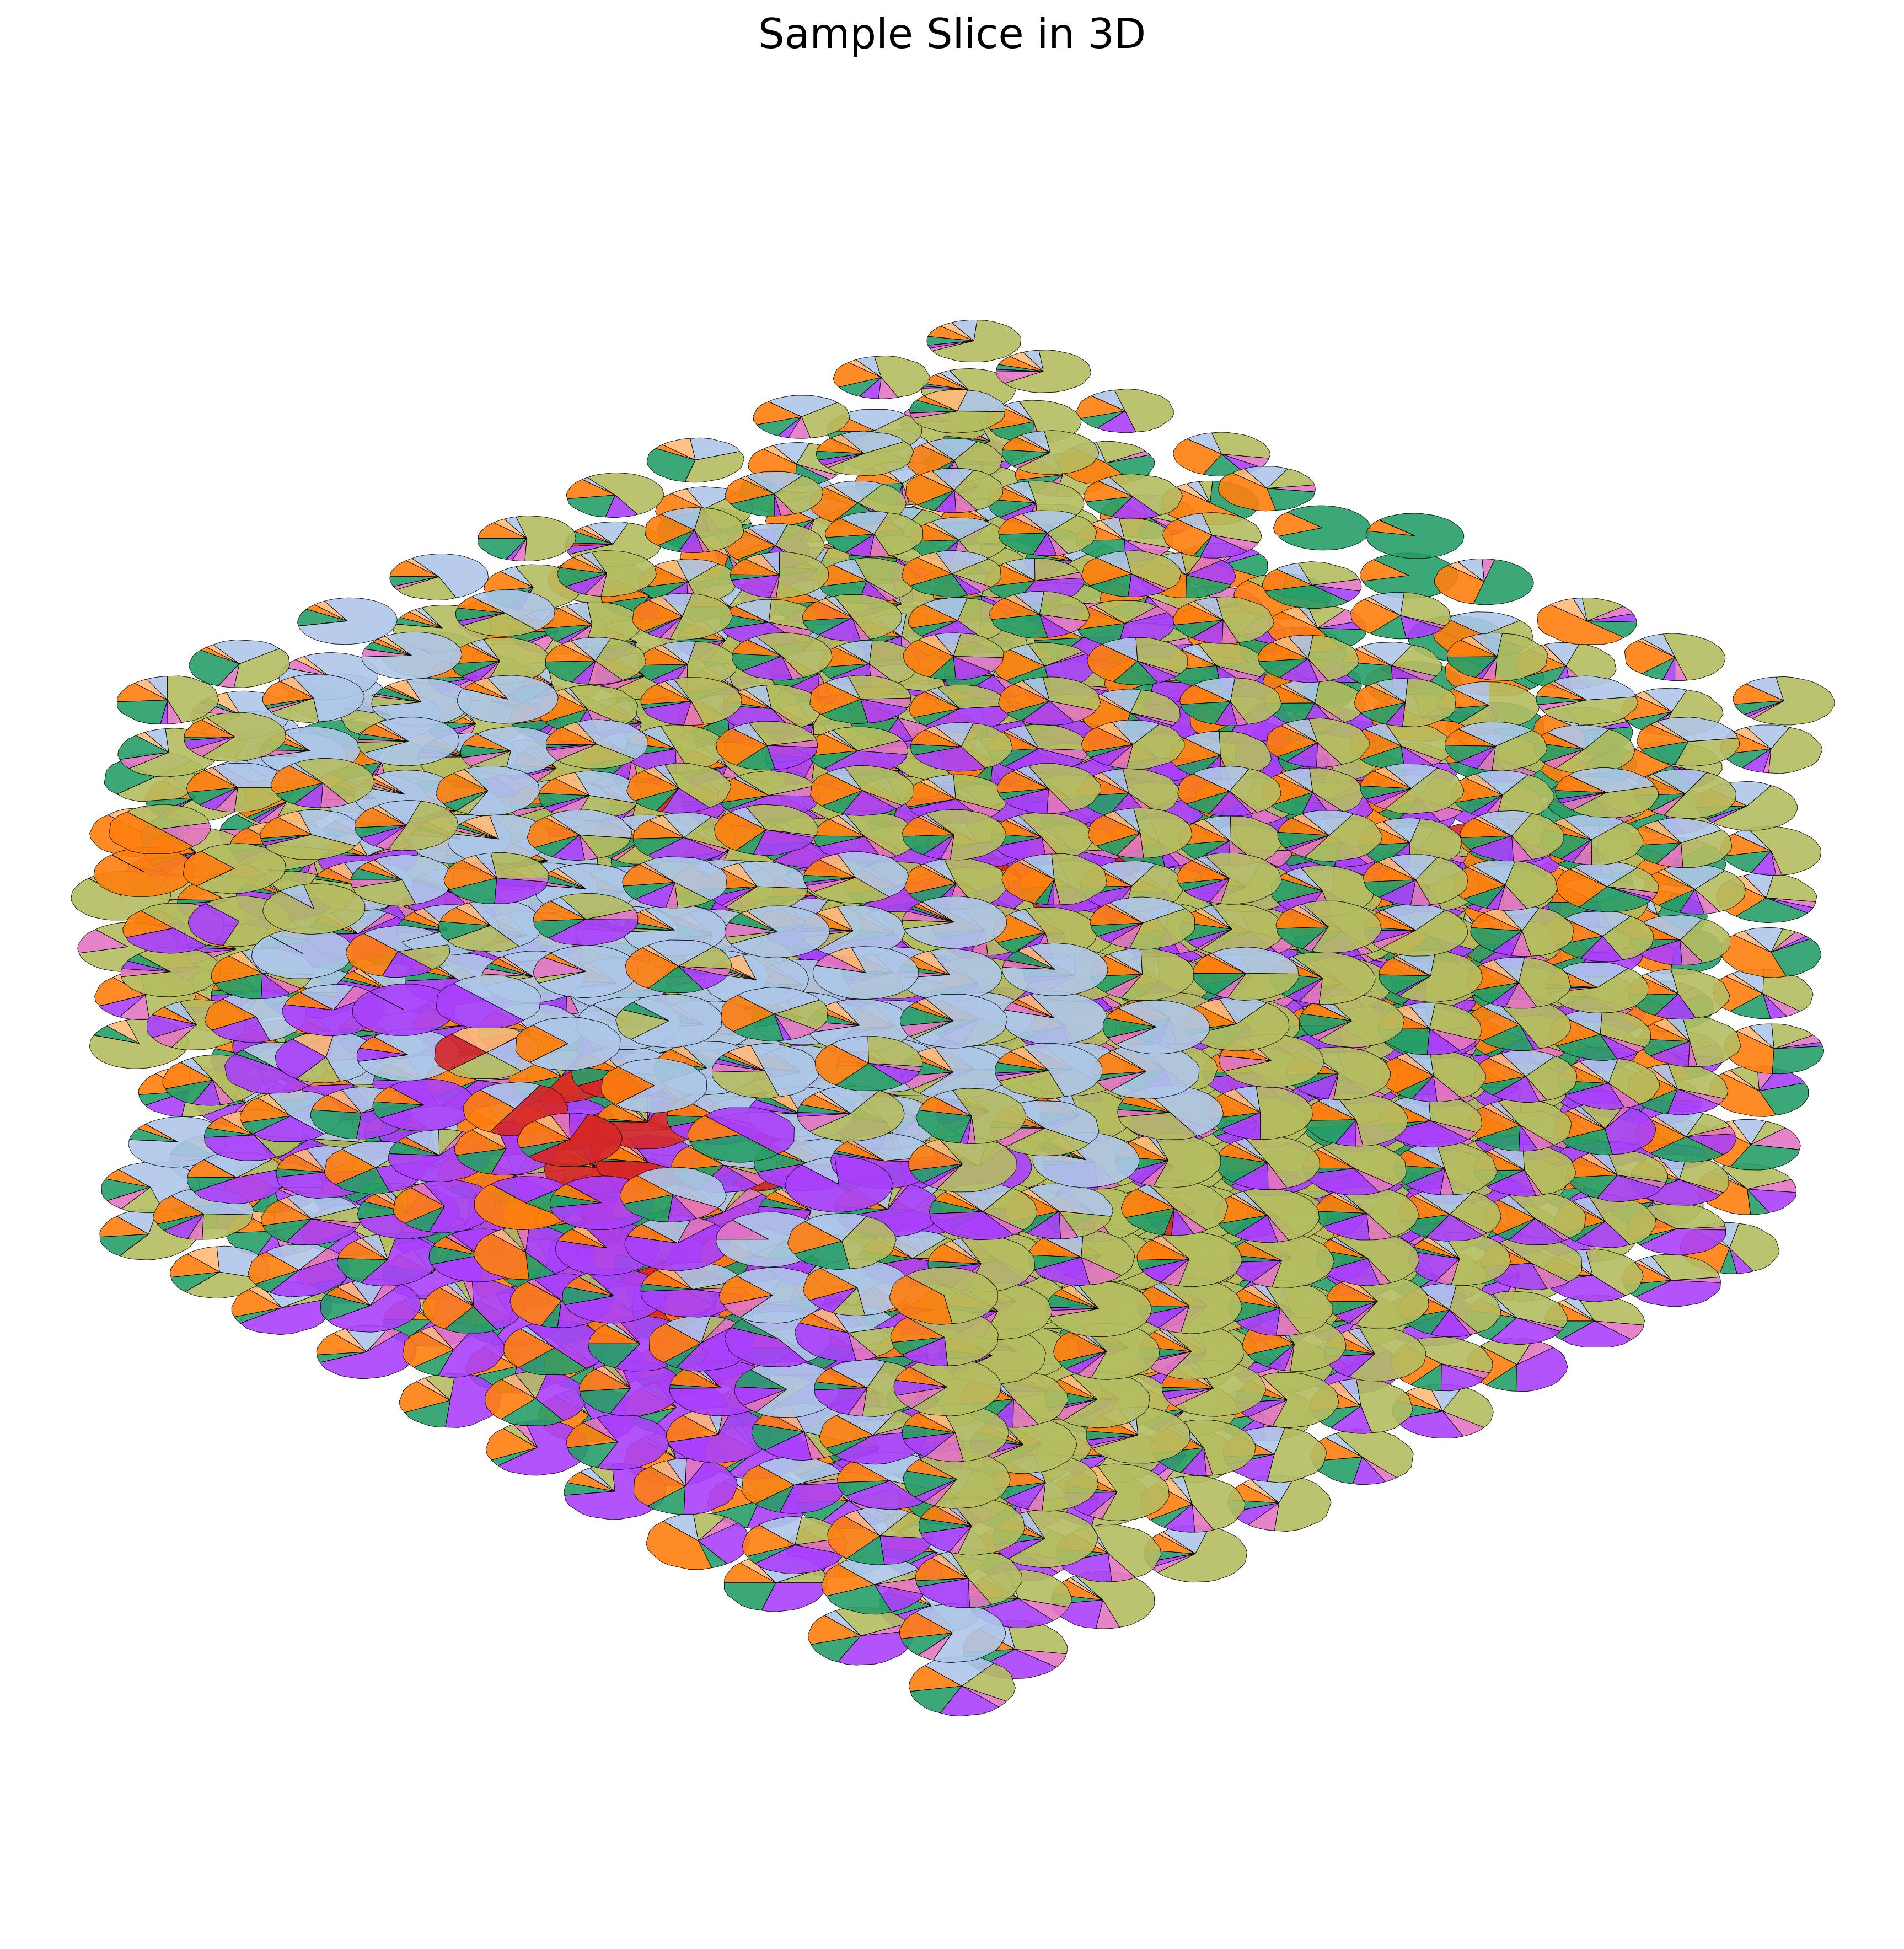

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


In [23]:
fig = viz_slice_spots_one_stacked_3d(
    adata_all,
    celltype_classes=celltype_classes,
    celltype_colors=celltype_colors,
    pie_size=0.04,legend=None,
    title="Sample Slice in 3D"
)
plt.show()


fig_path = os.path.join(figdir, "3D_stack.pdf")
fig.savefig(fig_path, dpi=1200, bbox_inches='tight')
plt.close(fig)

## Fig 3b

In [ ]:

spa_celltype_key='cell_type'

dataset = 'Moffitt2018'

scrna_cluster_key = "Cell class (determined from clustering of all cells)"

deconv_dir = figdir  + '/deconv/'
metrics_dir = figdir  + '/metrics/'


N = 50
nneigh = 10
nbdswaps = 2
par_lambda_curr = 0.1
# par_eta1_curr = 10.0
kernel3d_bw_slices_curr = 8
bandwidth_curr = 0.01
n_spatial_neigh_curr = 10
mode_nbd = 'variabletranscr'
gtalign = False # if True, use GT alignment 
aligntool = 'moscot'
key_name = 'linear_0'
num_augment = '20'
mode_nbd = 'variabletranscr'
augment = True
mode = 'multislice'



partesting_str =     '_partesting_' + 'parlambda_' + str(par_lambda_curr) +   '_parbw_' + str(bandwidth_curr) +  '_nbdtype_' + mode_nbd +  '_realalign_' + str(aligntool) 
res_file = 'metrics_' + mode + '_' + mode_nbd + '_sptsz_' + str(N)  + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + partesting_str +'_sc.pickle'
print(res_file)
with open(metrics_dir + res_file, 'rb') as handle:
    metrics_sc_ms = pickle.load(handle)


res_file = 'metrics_st1_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_CARD.pickle'
with open(metrics_dir + res_file, 'rb') as handle:
    metrics_card = pickle.load(handle)
metrics_card = metrics_card['linear_0']

res_file = 'metrics_st1_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_cell2location.pickle'
if os.path.exists(metrics_dir + res_file):
    with open(metrics_dir + res_file, 'rb') as handle:
        metrics_cell2loc = pickle.load(handle)
    metrics_cell2loc = metrics_cell2loc['linear_0']
else:
    # metrics_cell2loc = metrics_card.copy()
    print("not found cell2location metrics, skipping...")

res_file = 'metrics_st1_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_tangram.pickle'
with open(metrics_dir + res_file, 'rb') as handle:
    metrics_tangram = pickle.load(handle)
metrics_tangram = metrics_tangram['linear_0']

res_file = 'metrics_st1_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_tangramsc.pickle'
with open(metrics_dir + res_file, 'rb') as handle:
    metrics_tangramsc = pickle.load(handle)
metrics_tangramsc = metrics_tangramsc['linear_0']




all_algos =  {
              'SpaDecoder':metrics_sc_ms,
                'CARD':metrics_card,
                'Cell2location':metrics_cell2loc,
                'Tangram':metrics_tangram,
                'Tangramsc':metrics_tangramsc,
                }


result_metrics = ['orig_rmse_avg',  'avg_corr_pe_avg', 'avg_jsd_avg']
col_names = result_metrics.copy()
col_names.extend(['algo'])
res_df = pd.DataFrame(columns=col_names)
idx = 0



for algo_name, algo_res in all_algos.items():
    real_samp = list(algo_res.keys())
    # sim_samp = metrics_sc_ms[entry][real_samp[0]].keys()
    for real_samp_name in real_samp:

        tmp_df = algo_res[real_samp_name].loc[result_metrics,:].T
        tmp_df['algo'] = algo_name
        tmp_df['sample'] = real_samp_name
        res_df = pd.concat([res_df,tmp_df])


        
res_df['dataset'] = 'Moffitt2018'

metrics_multislice_variabletranscr_sptsz_50_nneigh_10_nbdswaps_2_partesting_parlambda_0.1_parbw_0.01_nbdtype_variabletranscr_realalign_moscot_sc.pickle


/tmp/ipykernel_1056785/3810879484.py:34: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  metrics_sc_ms = pickle.load(handle)
/tmp/ipykernel_1056785/3810879484.py:39: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If t

In [14]:
to_plot = ['SpaDecoder', 'CARD', 'Cell2location', 'Tangram', 'Tangramsc']


In [15]:
res_df['simidx'] = res_df.index

In [16]:
res_df = res_df[res_df['simidx'] == 0]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def grouped_barplot(df, group_col, category_col, group_order, algo_order, value_col, save_path=None, xlabel="Groups", ylabel="Value", title="Grouped Bar Plot"):
    """
    Creates a grouped barplot where one column indicates the group, and another column represents categories within the group.
    The mean value is plotted as the height of the bars, and the standard deviation is used for error bars.

    Parameters:
    - df: Input DataFrame with values.
    - group_col: Column name representing groups.
    - category_col: Column name representing categories within groups.
    - value_col: Column name containing the values to be plotted.
    - xlabel: Label for the x-axis.
    - ylabel: Label for the y-axis.
    - title: Plot title.
    """

    # Compute mean and standard deviation for each (group, category) combination
    summary_df = df.groupby([group_col, category_col])[value_col].agg(['mean', 'min','max']).reset_index()

    # Handle NaN standard deviation values by replacing them with 0
    # summary_df['std'] = summary_df['std'].fillna(0)

    # Get unique groups and categories
    groups = group_order #summary_df[group_col].unique()
    categories = algo_order #summary_df[category_col].unique()

    # Define bar width and spacing
    bar_width = 0.001  # Width of each bar
    group_spacing = 0.001  # Space between groups
    x = np.arange(len(groups)) * (len(categories) * bar_width + group_spacing)

    fig, ax = plt.subplots(figsize=(4, 6))

    # Plot bars for each category
    for i, category in enumerate(categories):
        subset = summary_df[summary_df[category_col] == category].copy()
        subset[group_col] = pd.Categorical(subset[group_col], categories=group_order, ordered=True)
        subset = subset.sort_values(by=group_col)
        
        x_positions = x + i * bar_width
        means = subset['mean'].values
        # errors = subset['std'].values  # Standard deviation as error bars
        y_err = np.stack([subset['mean'].values - subset['min'].values, subset['max'].values - subset['mean'].values])
        # print(errors)
        # print(x_positions)
        # print(means)
        ax.bar(
            x_positions,
            means,
            bar_width,
            yerr=y_err,
            capsize=5,
            label=category
        )


        # Annotate each bar with its mean value
        for xpos, mean, err in zip(x_positions, means, y_err.T):
            # Adjust the offset (0.01) as needed for clarity.
            ax.text(xpos, mean + err[1] + 0.001, f'{mean:.4f}', ha='center', va='bottom', fontsize=12)


    # Customize x-axis
    ax.set_xticks(x + bar_width * (len(categories) - 1) / 2)
    ax.set_xticklabels(groups, rotation=0, fontsize=24)
    ax.tick_params(axis='y', labelsize=24)

    # Add labels, title, and legend
    # ax.set_xlabel(xlabel, fontsize=24)
    ax.set_ylabel(ylabel, fontsize=24)
    # ax.set_title(title, fontsize=24)
    # ax.legend(title="Categories", fontsize=24, title_fontsize=14,loc='upper left', bbox_to_anchor=(1.02, 1))
    # ax.tick_params(axis='x', labelrotation=45)
    # Adjust layout and show plot
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=1200, bbox_inches='tight')
    plt.show()



# df = pd.DataFrame(data)
# dataset_newname = {  'Moffitt2018':'Moffitt2018','Choi2023':'Choi2023',# 'dataset3_seqfishpluscai':'Eng2019No.2', 
#                     # 'dataset4_seqfishpluscai':'Eng2019',  'dataset5_starmap_mousevisualcortex':'Wang2018', 
#                     'Haviv2025':'Haviv2025'}
dataset = [  'Moffitt2018']# 'Moffitt2018-high',
          #  'Choi2023',# 'Choi2023-high',# 'dataset3_seqfishpluscai', 'dataset4_seqfishpluscai',  'dataset5_starmap_mousevisualcortex',
           #  'Haviv2025']# 'Haviv2025-high']
result_metric_newname = {'orig_rmse_avg':'RMSE','avg_corr_pe_avg':'Aver Corr','avg_jsd_avg':'Aver JSD'}

# Plot using the function
# for metric in result_metrics:
#     grouped_barplot(res_df3, group_col="dataset", category_col="algo", group_order=list(dataset_newname.values()),algo_order=list(all_algos.keys()), value_col=metric,xlabel='Methods Across Datasets',ylabel=result_metric_newname[metric],title=result_metric_newname[metric] + ' Metric')

# res_df_tmp = res_df[res_df['dataset']=='Haviv2025']
for metric in result_metrics:
    grouped_barplot(res_df, group_col="dataset", category_col="algo", group_order=dataset,algo_order=to_plot, save_path=figdir + metric + '_jan2026.pdf',value_col=metric,xlabel='Datasets',ylabel=result_metric_newname[metric],title= 'Moffitt2018')
    # plt.savefig(*args 

In [24]:
res_df.to_csv(figdir + 'metrics_summary.csv')